## Imports

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
!echo $CUDA_VISIBLE_DEVICES

0


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import matplotlib.pyplot as plt
import torch.distributions as D
import csv
from matplotlib.animation import FuncAnimation, PillowWriter
from torch import Tensor

In [3]:
torch.cuda.empty_cache()

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:
import os
import sys
sys.path.append("..")
from Samplers.sampling import langevin_sampler, NET_Sampler
from Models.models import *
from Energies.gmm import *
from Energies.interpolations import *
from Training.train import *
from Testing.test import *
from Utils.constants import means_40
from Utils.plotting import * 
from Utils.metrics import *
from Utils.misc import *

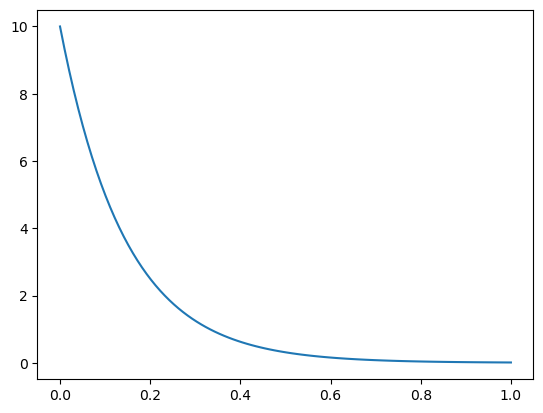

In [9]:
t_ = torch.linspace(0, 1, 100)
betas = beta_schedule(t_)
plt.plot(t_, betas)

## Sample process AIS 

- Need to make config files to make this easier

In [10]:
# seeds 38, 35, 40
torch.manual_seed(40)

epsilon = 10
n_steps = 250
T = 1
dt = T / n_steps
# grid, dt = build_time_grid(n_steps, T)
num_samples = 2000
perturbation = 0.0
means = None
modes = not None
dim = 2
num_components = 2
U_net = None
# covs = None
# covs = torch.tensor([5.0], dtype=torch.float32).to(device)
covs = torch.tensor([1, 4], dtype=torch.float32).to(device)
# covs = 3 * torch.tensor([0.1, 0.3, 0.5, 0.7], dtype=torch.float32).to(device)
# covs = torch.tensor([1, 1, 1, 1], dtype=torch.float32).to(device)
# covs = 10 * torch.rand(num_components, device=device)
weights = torch.tensor([0.5, 0.5], dtype=torch.float32).to(device)
# weights = torch.tensor([0.3, 0.1, 0.2, 0.4], dtype=torch.float32).to(device)
# weights = torch.tensor([1.0], dtype=torch.float32, device=device)
mixture = create_gaussian_mixture(dim, num_components, covs=covs, weights=weights, device=device)
true_modes = mixture.component_distribution.mean
warm_starts = true_modes + perturbation * torch.randn(num_components, dim).to(device)
# means = true_modes
project_root = os.path.abspath("..")
load_dir = os.path.join(project_root, f'alps_interpolation/{dim}d_{num_components}gmm')

RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [8]:
true_samples = torch.stack([mixture.sample() for i in range(num_samples)])

p(t) at modes: [0.5 0.5]


/Users/dilumfernando/projects/NETs/Code/../Utils/plotting.py:362: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


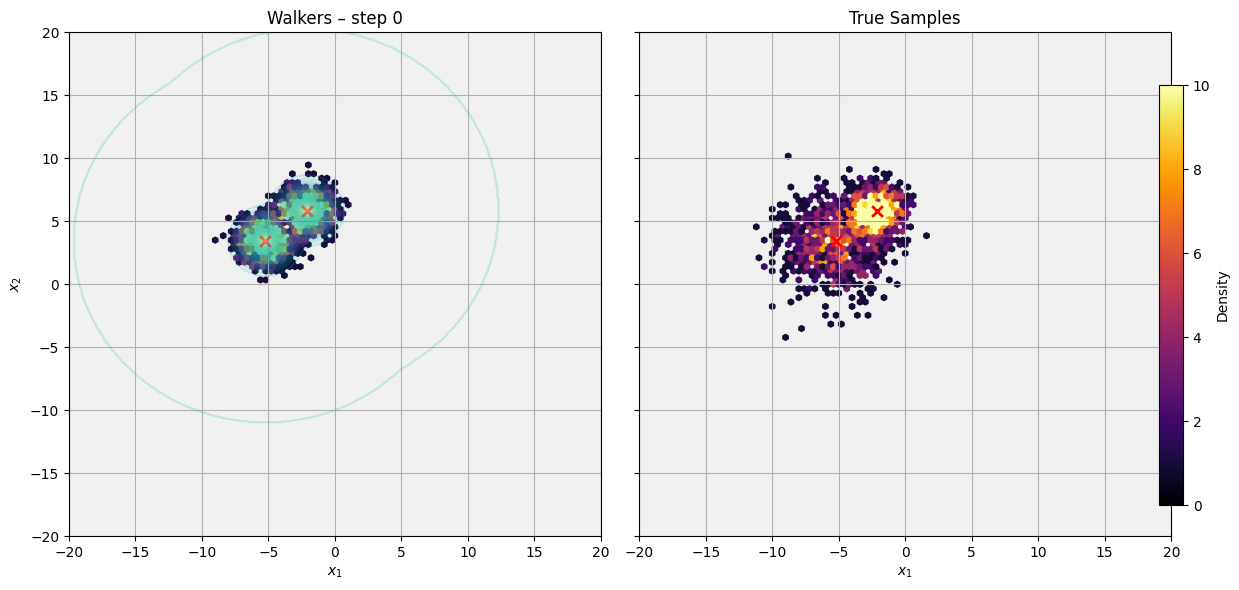

mode weights from walkers: [0.49875444 0.50124556]
p(t) at modes: [0.51419777 0.48580226]


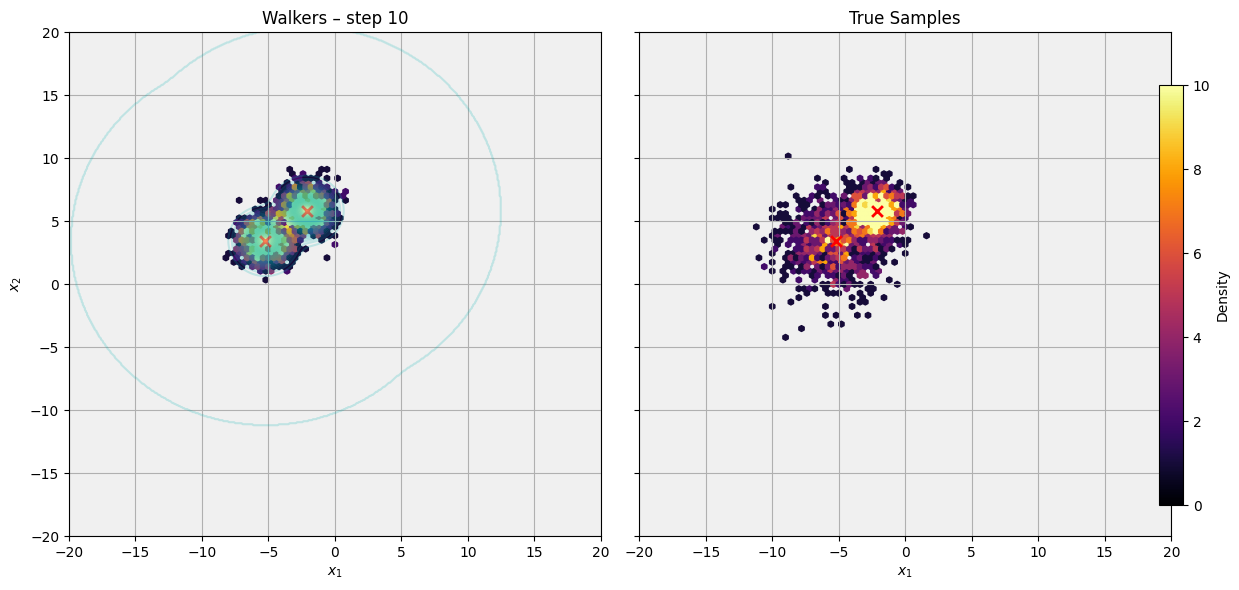

mode weights from walkers: [0.49644607 0.5035539 ]
p(t) at modes: [0.52837265 0.47162738]


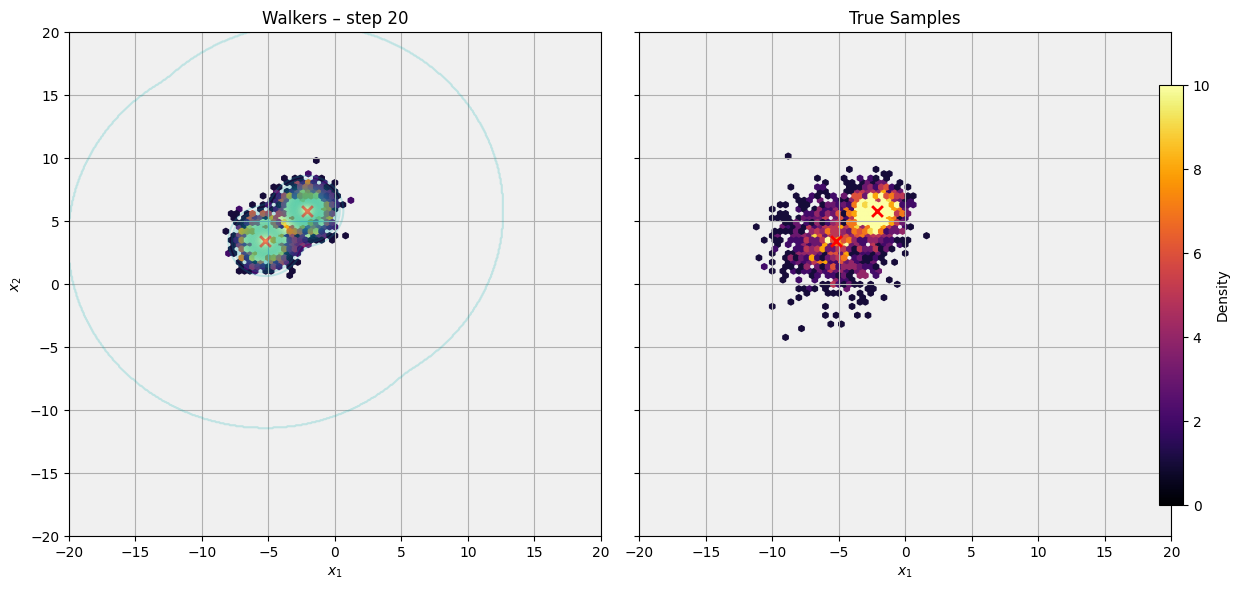

mode weights from walkers: [0.5136098  0.48639023]
p(t) at modes: [0.54250187 0.4574981 ]


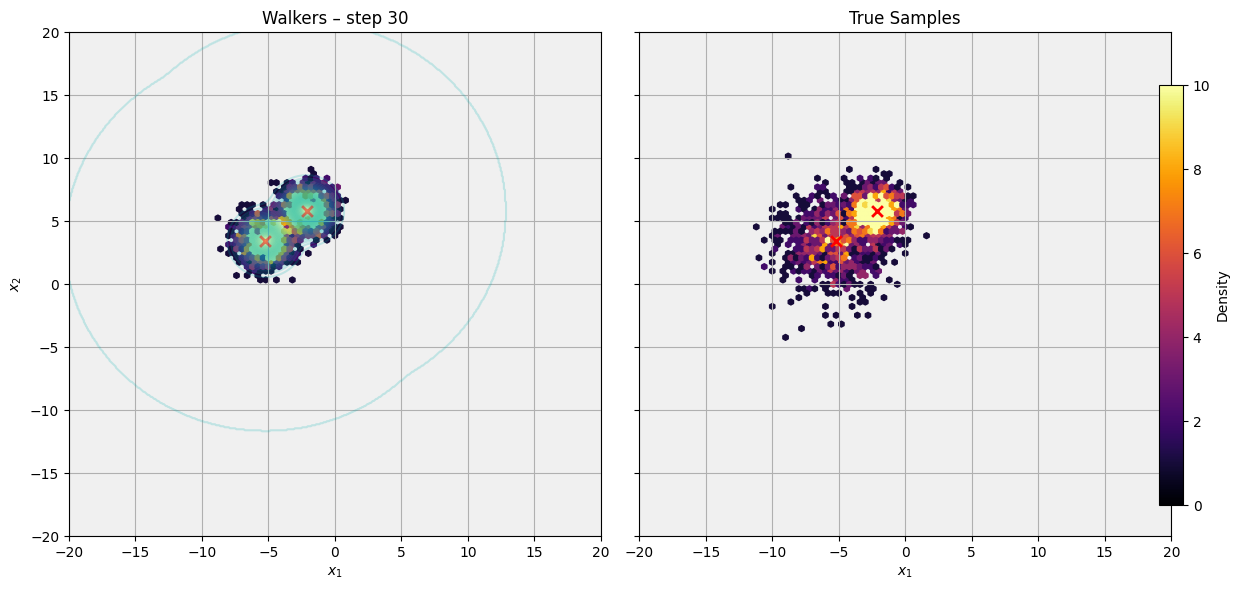

mode weights from walkers: [0.50647235 0.49352765]
p(t) at modes: [0.5565631 0.4434369]


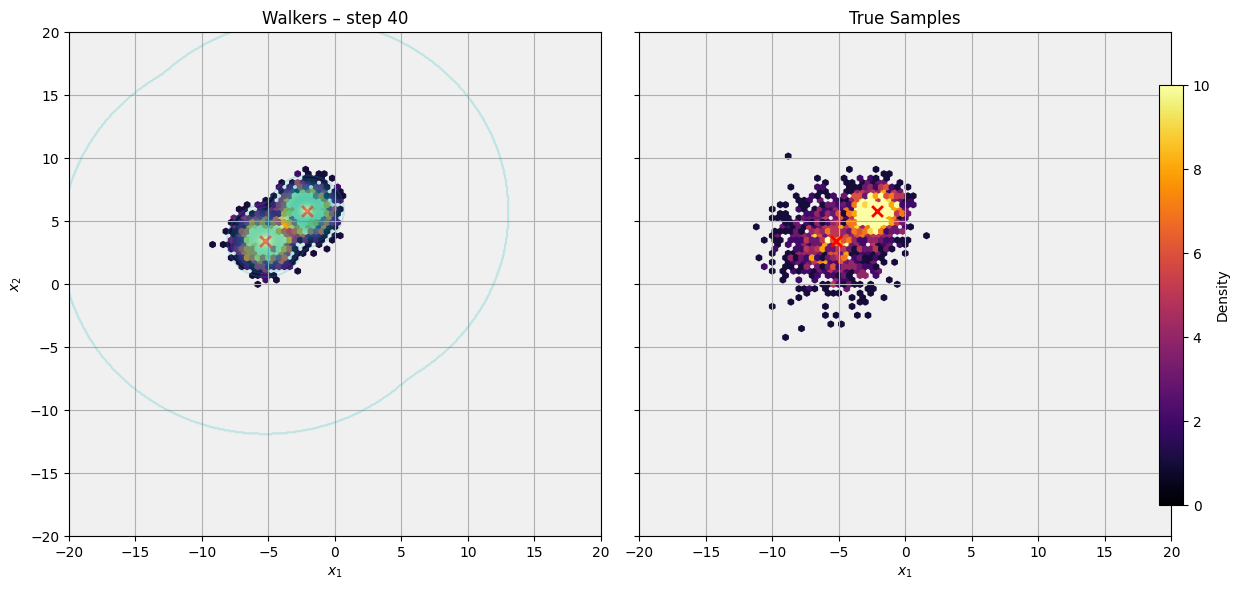

mode weights from walkers: [0.5278906  0.47210935]
p(t) at modes: [0.5705343  0.42946565]


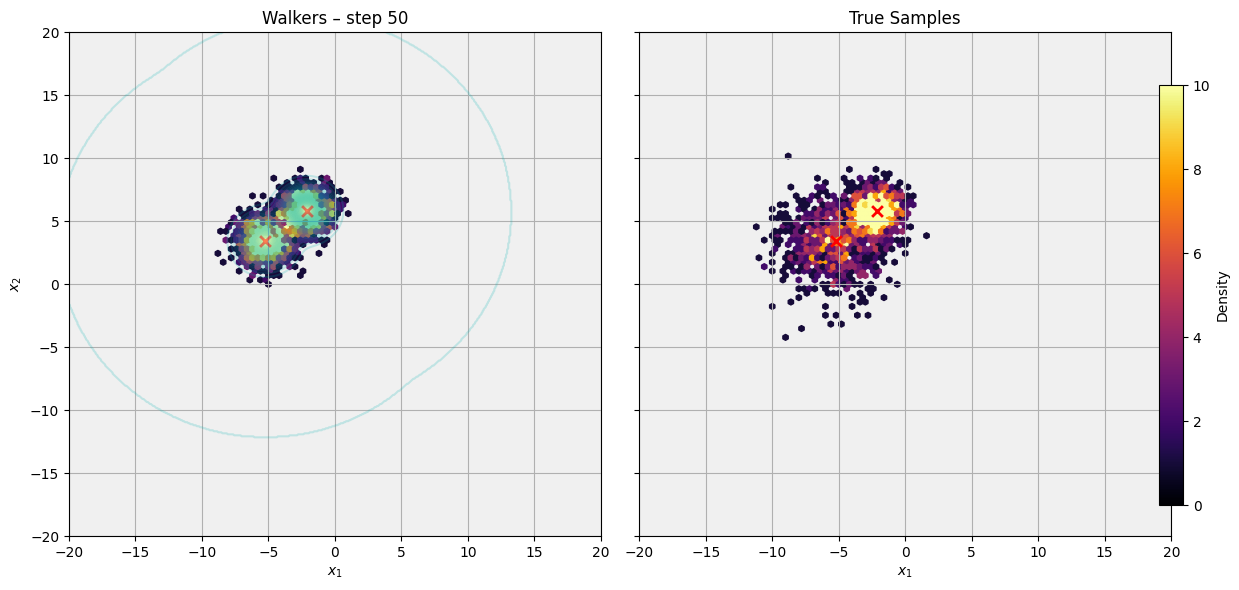

mode weights from walkers: [0.5283111  0.47168896]
p(t) at modes: [0.58439404 0.41560602]


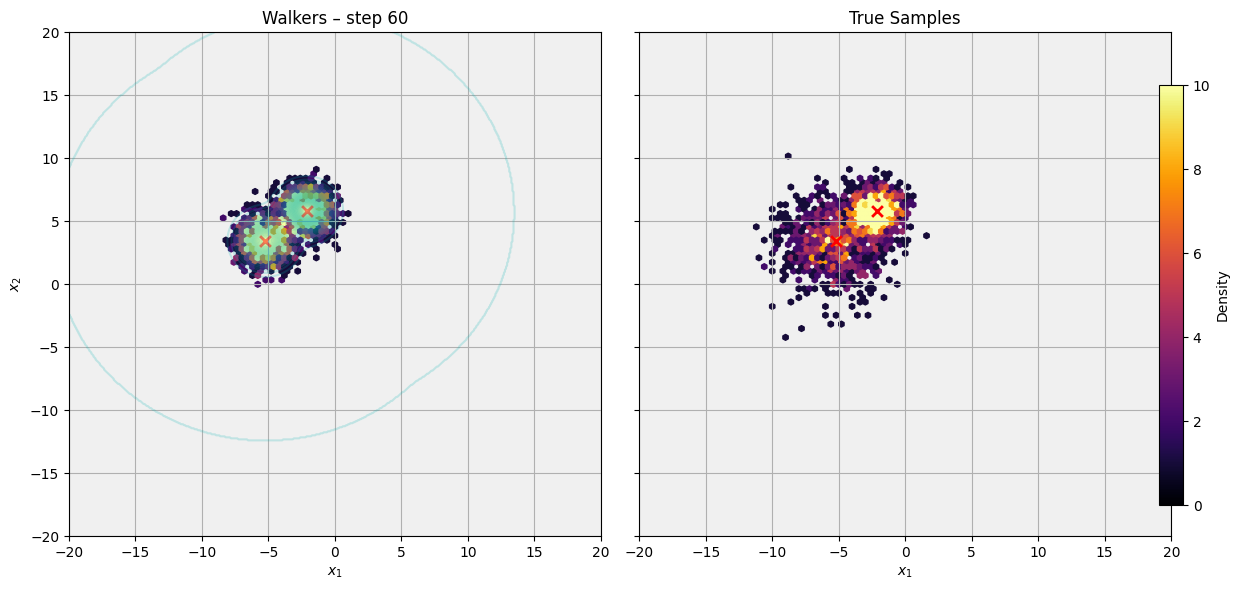

mode weights from walkers: [0.5365277  0.46347228]
p(t) at modes: [0.5981215  0.40187854]


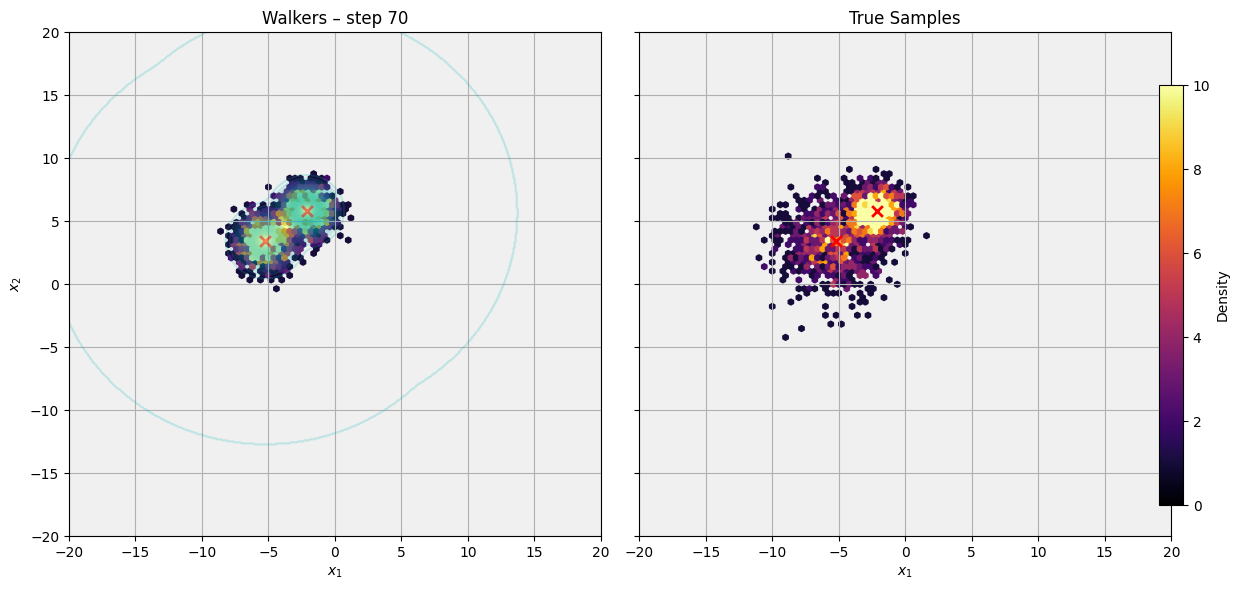

mode weights from walkers: [0.54034406 0.45965588]
p(t) at modes: [0.6116968  0.38830322]


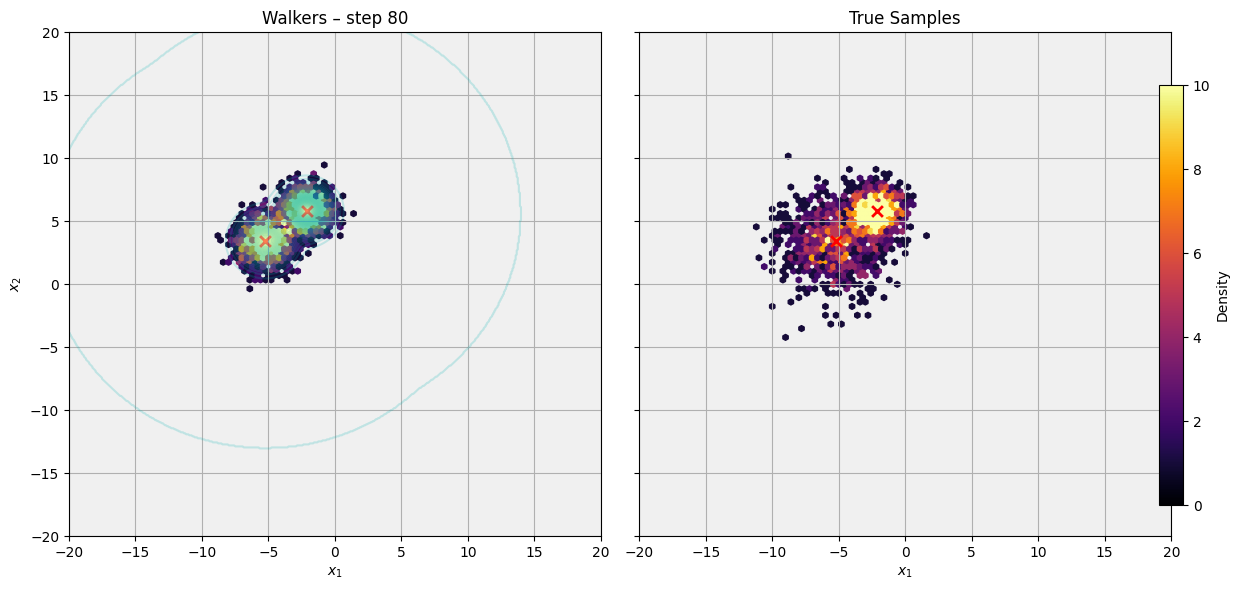

mode weights from walkers: [0.5414936  0.45850646]
p(t) at modes: [0.62510103 0.374899  ]


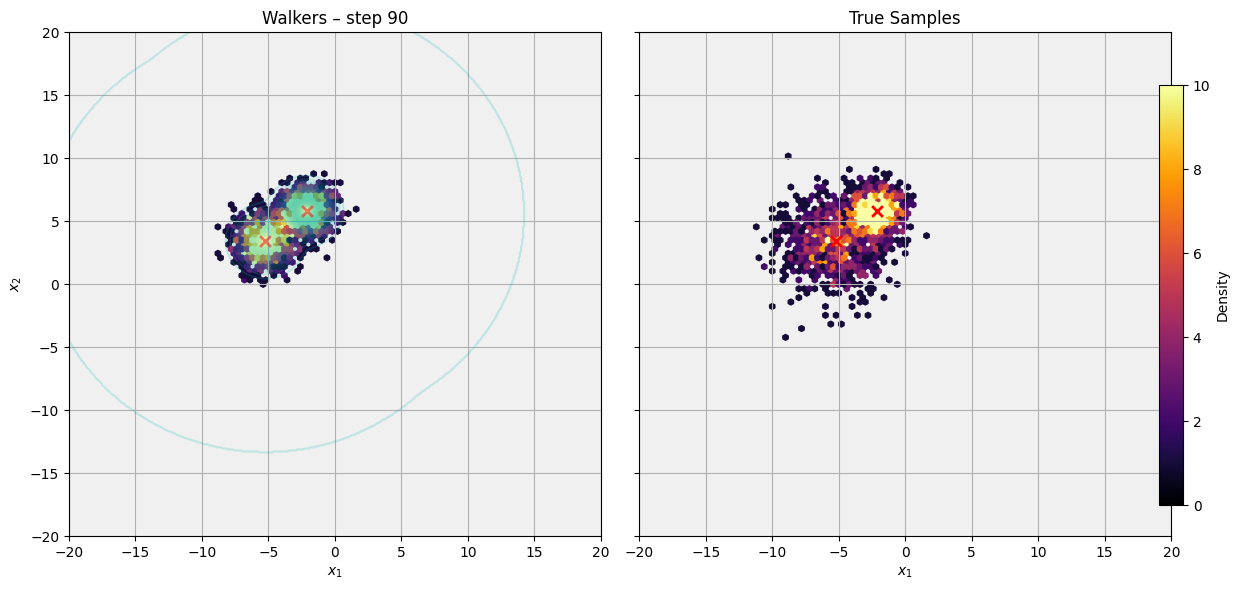

mode weights from walkers: [0.5462084  0.45379162]
p(t) at modes: [0.6383161 0.3616839]


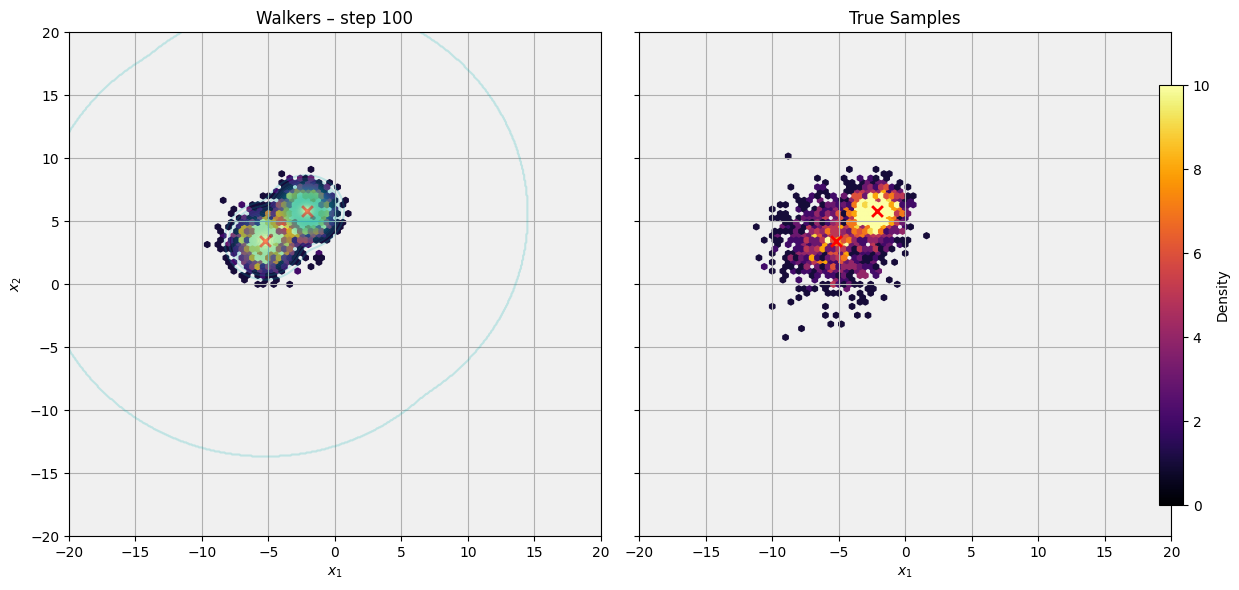

mode weights from walkers: [0.5483285 0.4516715]
p(t) at modes: [0.65132517 0.34867483]


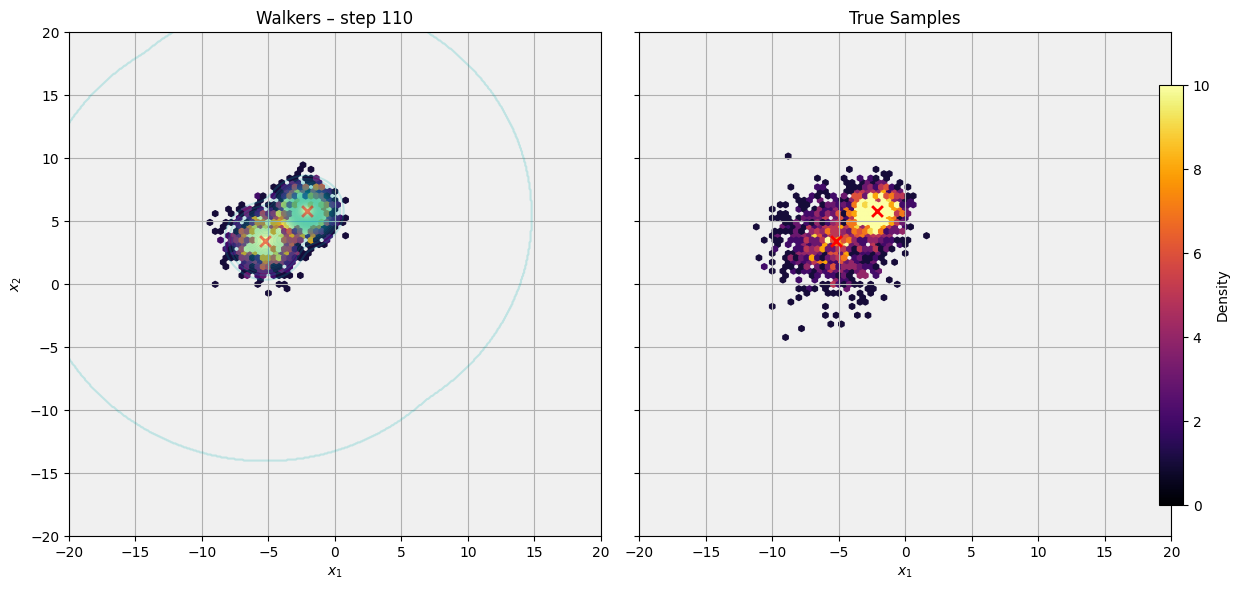

mode weights from walkers: [0.5549443  0.44505566]
p(t) at modes: [0.6641125  0.33588746]


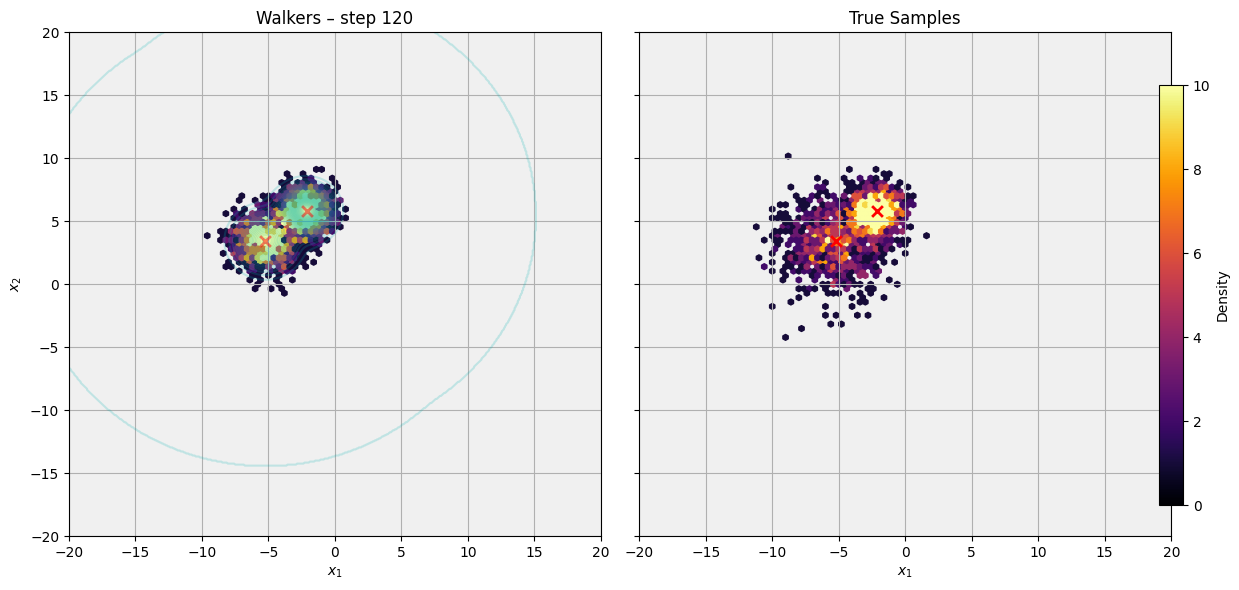

mode weights from walkers: [0.5562737 0.4437263]
p(t) at modes: [0.6766637 0.3233362]


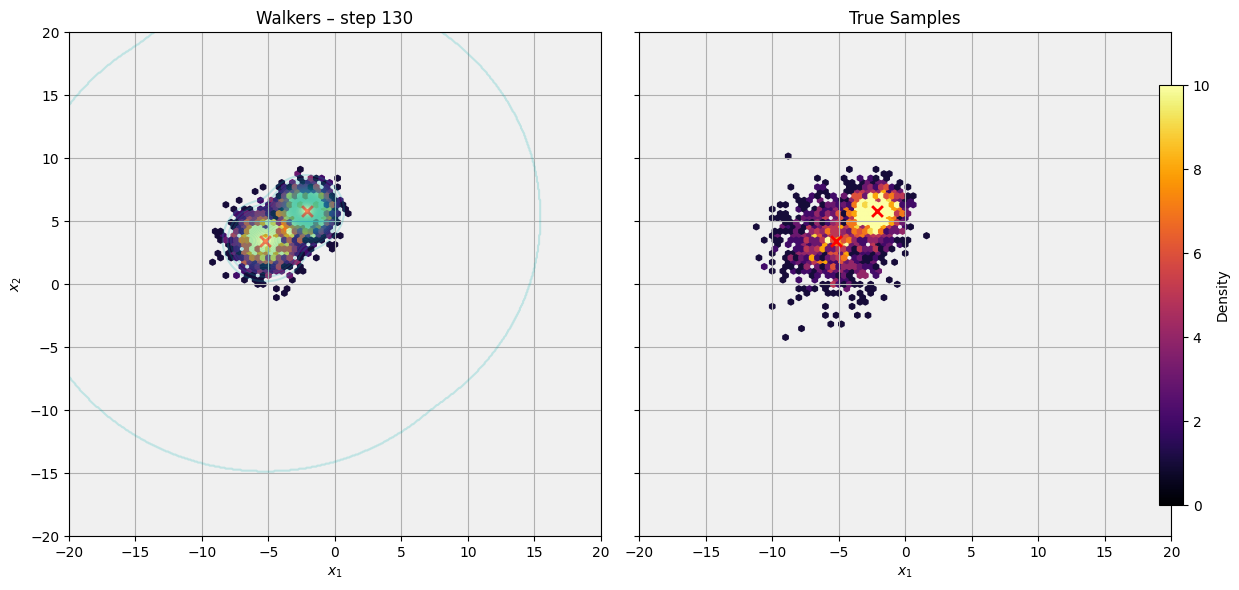

mode weights from walkers: [0.5576023 0.4423977]
p(t) at modes: [0.6889657  0.31103435]


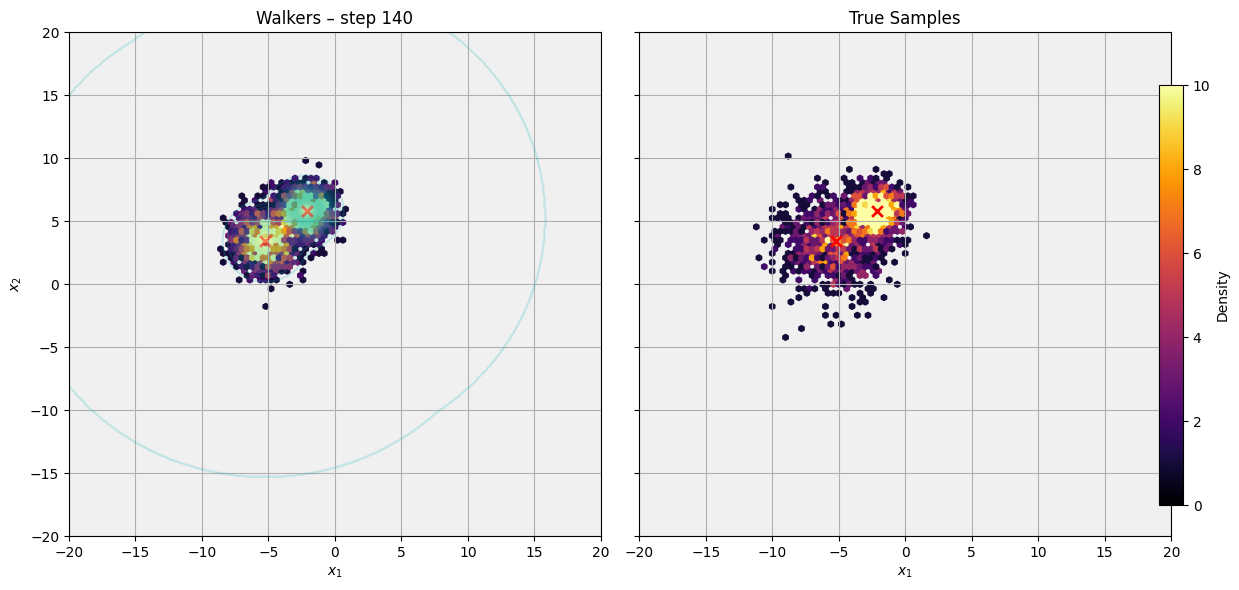

mode weights from walkers: [0.55897015 0.4410299 ]
p(t) at modes: [0.7010063  0.29899374]


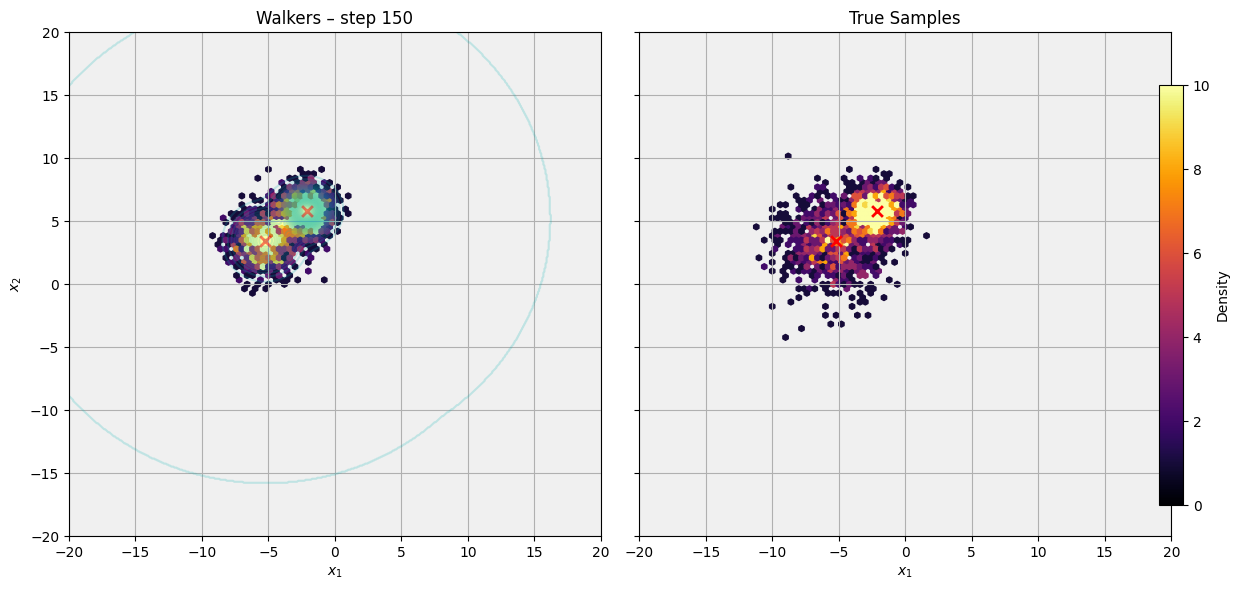

mode weights from walkers: [0.56151015 0.43848985]
p(t) at modes: [0.7127752 0.2872249]


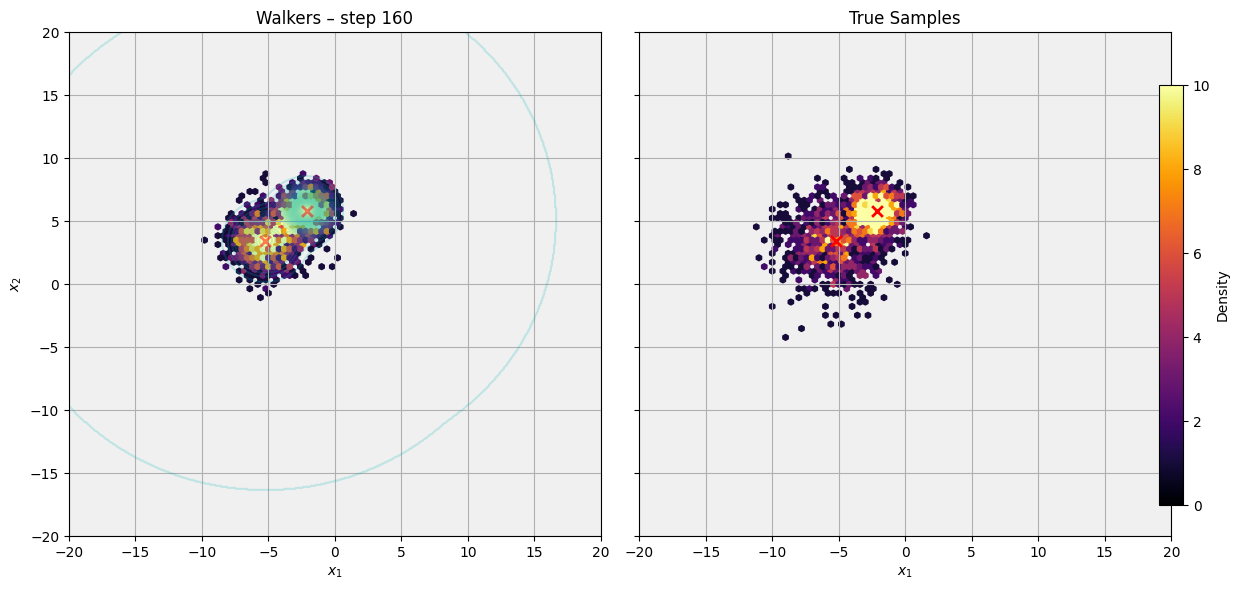

mode weights from walkers: [0.5689325  0.43106753]
p(t) at modes: [0.72426295 0.27573708]


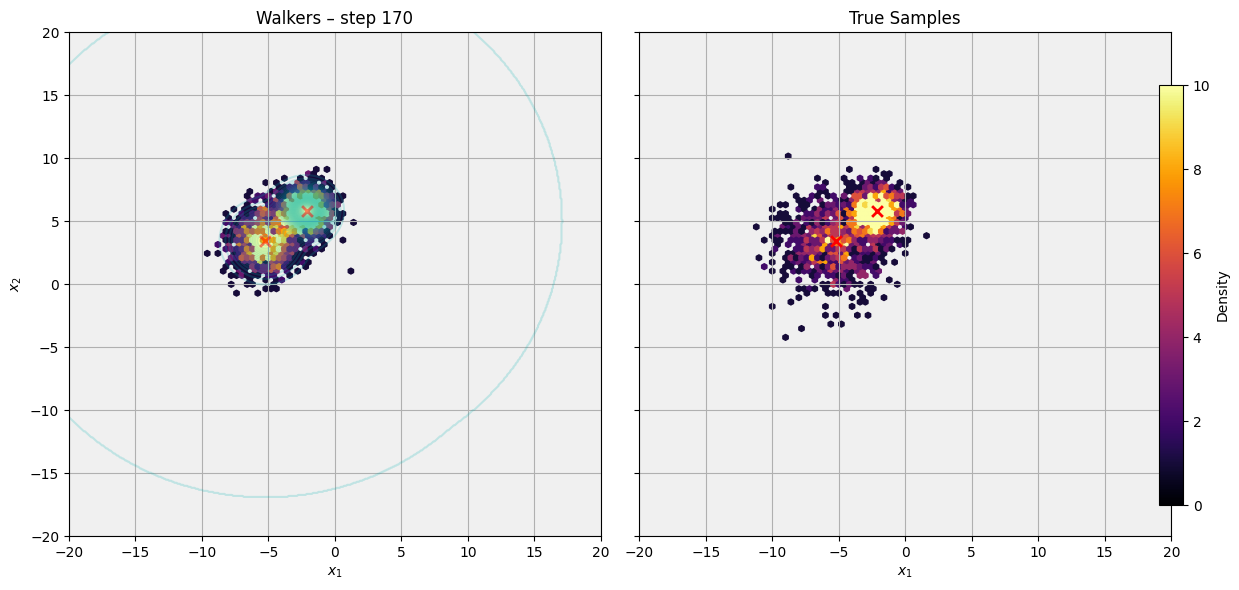

mode weights from walkers: [0.5699937  0.43000633]
p(t) at modes: [0.73546183 0.26453817]


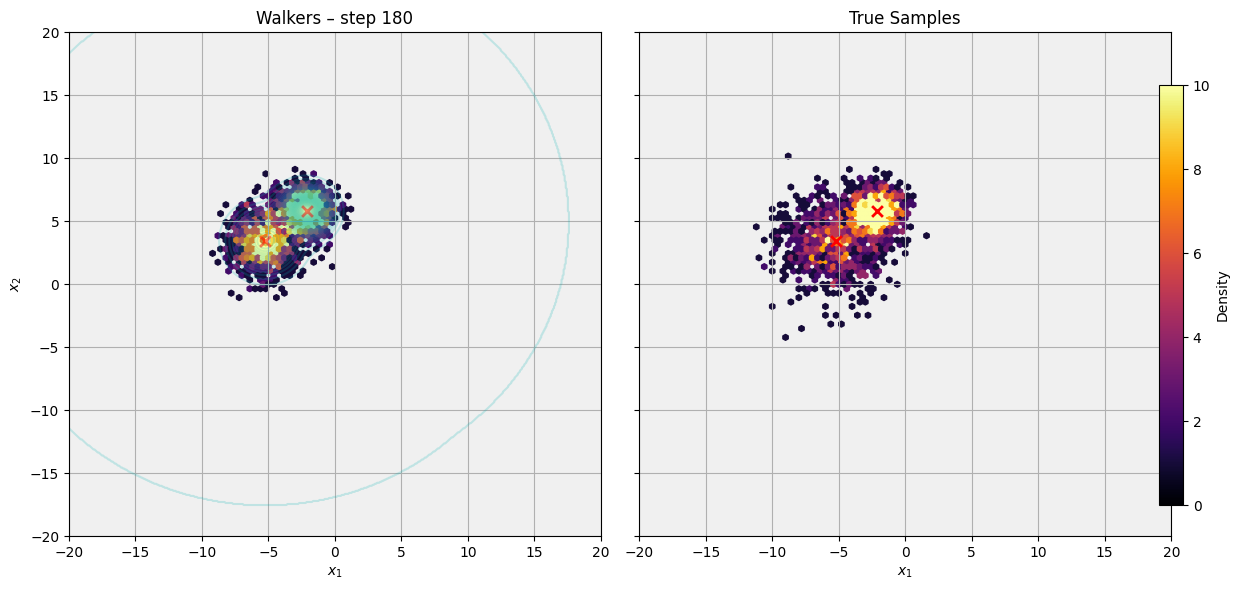

mode weights from walkers: [0.57107383 0.42892617]
p(t) at modes: [0.7463652  0.25363478]


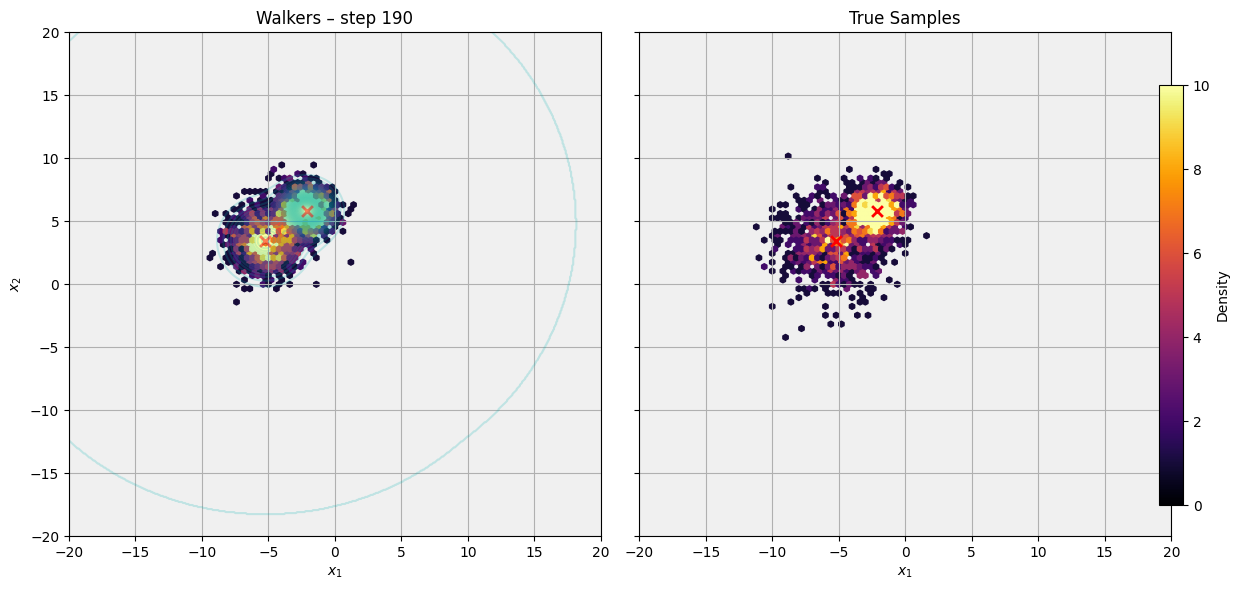

mode weights from walkers: [0.5718895  0.42811054]
p(t) at modes: [0.7569676  0.24303237]


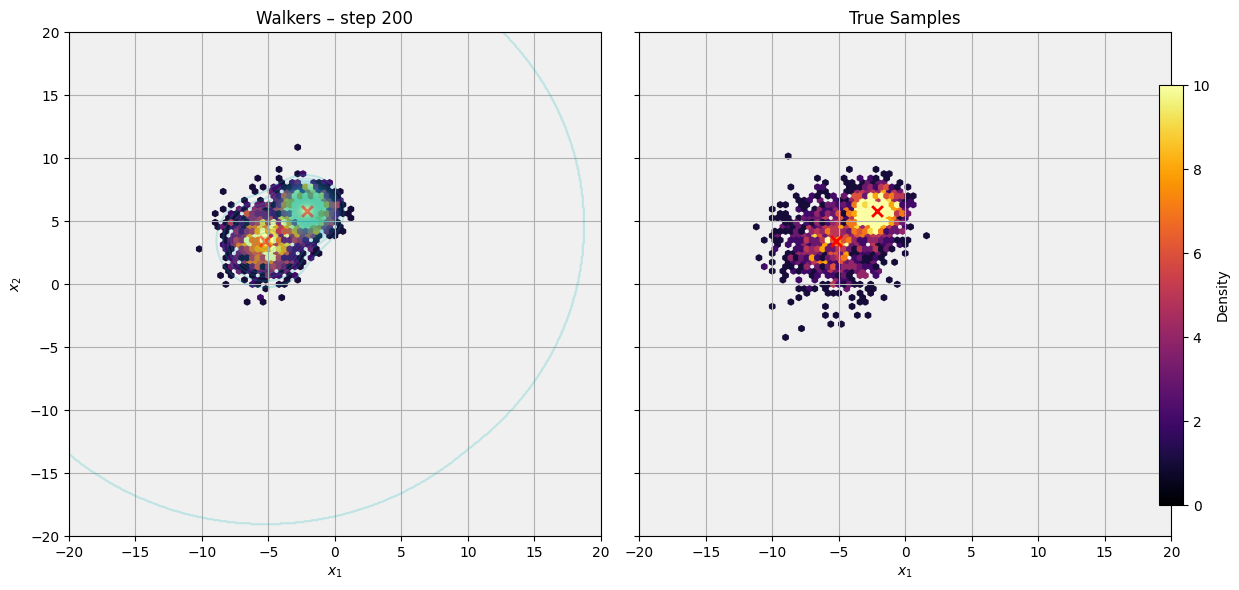

mode weights from walkers: [0.5814336  0.41856638]
p(t) at modes: [0.7672651  0.23273495]


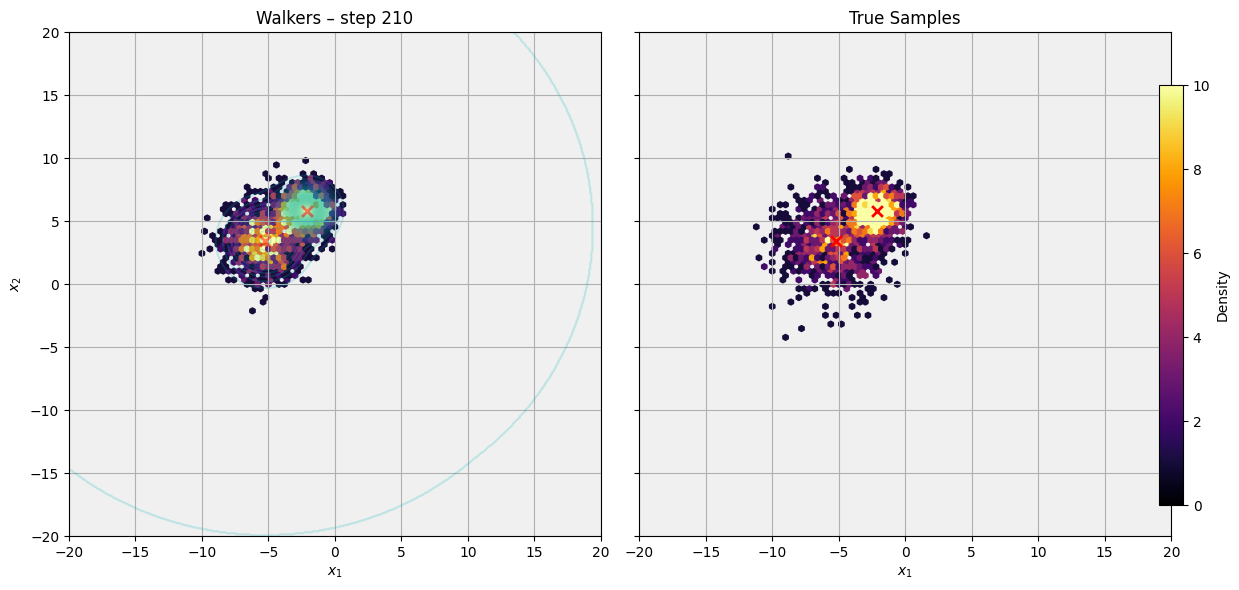

mode weights from walkers: [0.5855194 0.4144806]
p(t) at modes: [0.7772546  0.22274542]


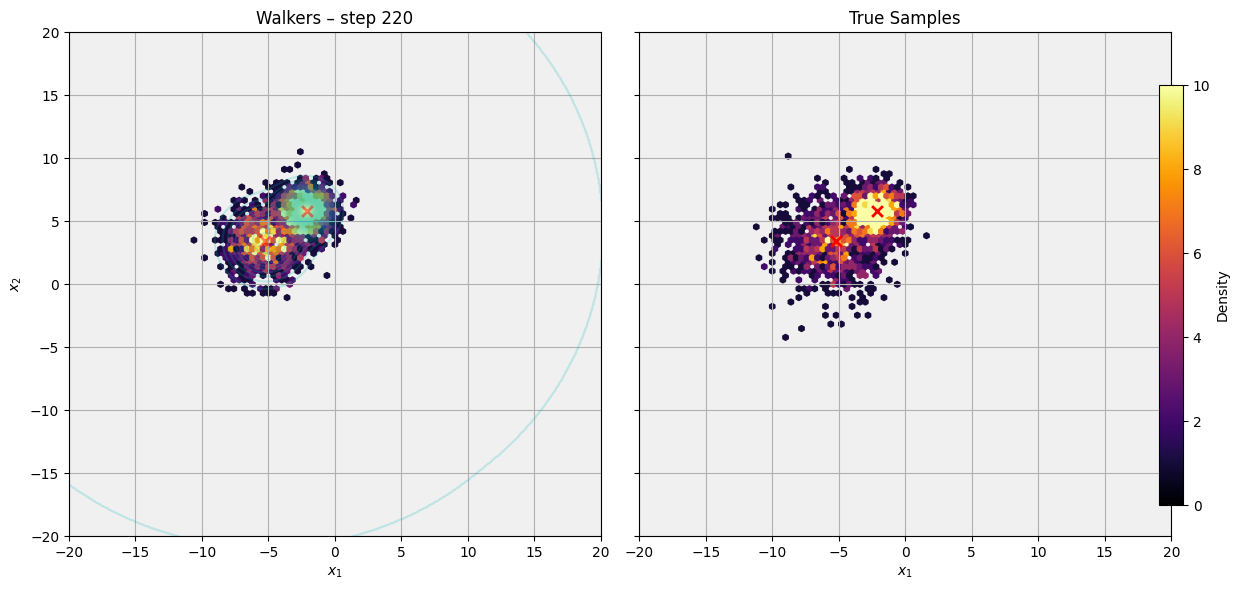

mode weights from walkers: [0.5812786 0.4187214]
p(t) at modes: [0.7869344 0.2130656]


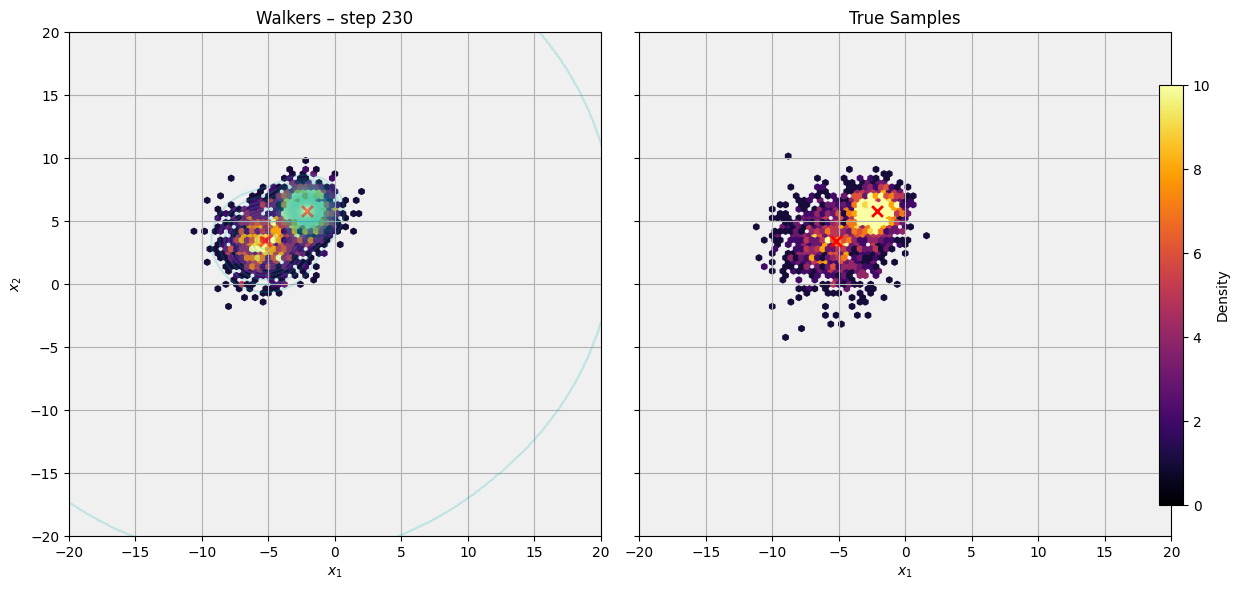

mode weights from walkers: [0.5842601 0.4157399]
p(t) at modes: [0.79630375 0.20369624]


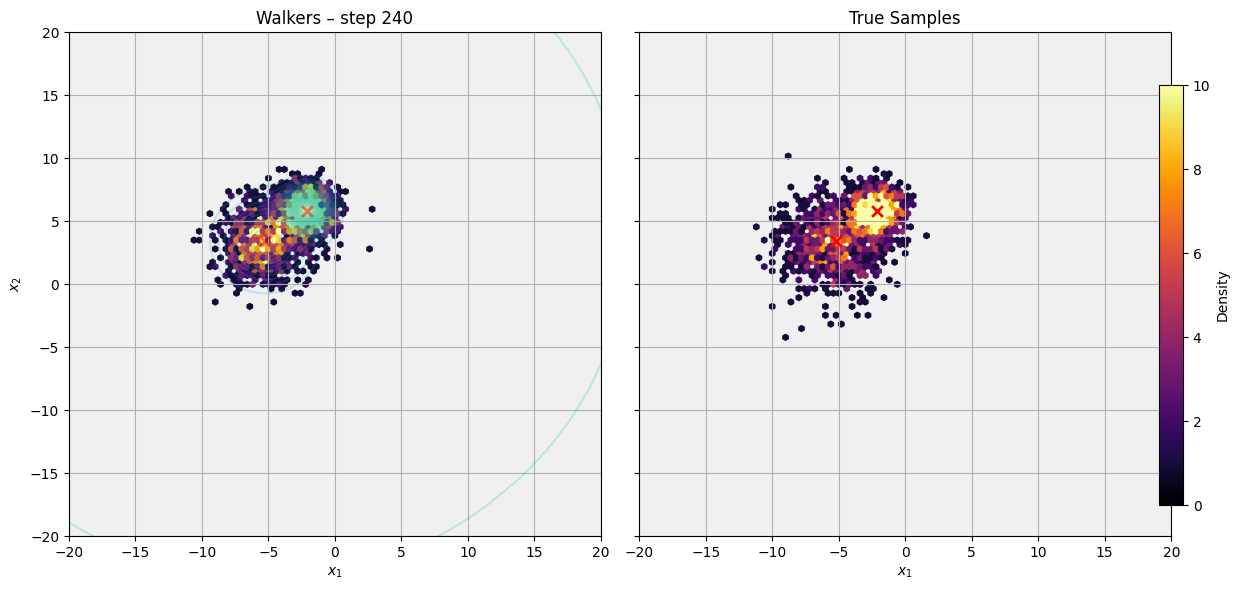

mode weights from walkers: [0.56972736 0.43027264]
p(t) at modes: [0.80536306 0.19463693]


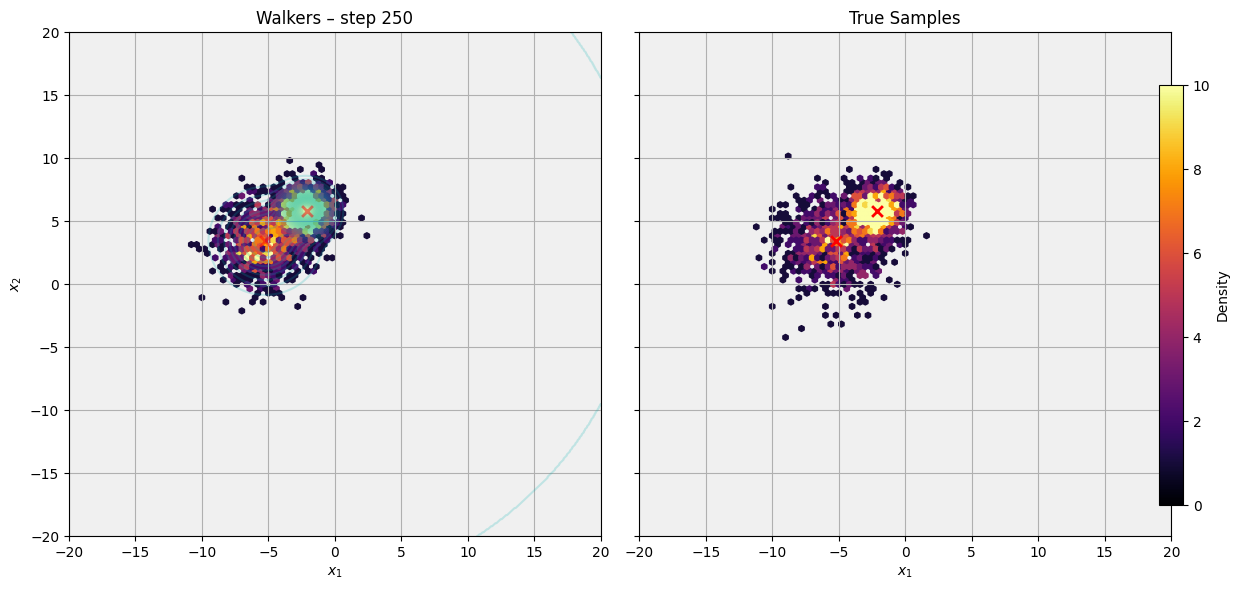

mode weights from walkers: [0.5574033  0.44259667]
tensor([0.0000, 0.9240, 0.9246, 0.9251, 0.9260, 0.9270, 0.9281, 0.9294, 0.9306,
        0.9320, 0.9332, 0.9344, 0.9356, 0.9365, 0.9375, 0.9384, 0.9393, 0.9401,
        0.9408, 0.9414, 0.9420, 0.9426, 0.9432, 0.9438, 0.9443, 0.9447, 0.9451,
        0.9455, 0.9460, 0.9465, 0.9470, 0.9474, 0.9479, 0.9482, 0.9485, 0.9488,
        0.9490, 0.9492, 0.9494, 0.9496, 0.9499, 0.9501, 0.9504, 0.9507, 0.9510,
        0.9513, 0.9517, 0.9520, 0.9524, 0.9527, 0.9530, 0.9534, 0.9536, 0.9539,
        0.9542, 0.9545, 0.9548, 0.9550, 0.9553, 0.9556, 0.9558, 0.9561, 0.9564,
        0.9566, 0.9568, 0.9570, 0.9573, 0.9575, 0.9578, 0.9580, 0.9583, 0.9585,
        0.9588, 0.9590, 0.9593, 0.9595, 0.9597, 0.9599, 0.9602, 0.9604, 0.9606,
        0.9608, 0.9611, 0.9613, 0.9616, 0.9618, 0.9620, 0.9621, 0.9623, 0.9625,
        0.9627, 0.9628, 0.9630, 0.9631, 0.9633, 0.9634, 0.9636, 0.9637, 0.9638,
        0.9640, 0.9641, 0.9642, 0.9643, 0.9644, 0.9645, 0.9646, 0.964

In [9]:
beta_max = torch.tensor(1)
init_logits = None
init_covs = (1 / beta_max) * torch.ones(num_components, device=device)
# init_covs = None
prior = LearnableGMM(means=warm_starts, covs=init_covs, logits=init_logits)
energy_model = GMMModesEnergy(warm_starts, beta_max) 
x0 = prior.distribution.sample(torch.Size((num_samples,)))


A0 = torch.zeros(num_samples, device=device)
x_langevin, A_langevin = langevin_sampler(x0, A0, dt = dt, steps=n_steps, 
                                          epsilon=epsilon, means=means, U_net=U_net, 
                                          modes=warm_starts,
                                          mixture=mixture,
                                          prior=prior,
                                          energy_model=energy_model,
                                          true_modes=true_modes,
                                          true_samples=true_samples,
                                          device=device)

ess_langevin = ess_eval(A_langevin)
print(ess_langevin)

In [10]:
X, log_weights = x_langevin[-1], A_langevin[-1]
weights_ = log_weights.exp()

labels = label_assignment_hard(X, true_modes)
labels_true = label_assignment_hard(true_samples, true_modes)

w = normalize_weights(weights_)

mode_weights = torch.stack([
    w[labels == k].sum()
    for k in torch.unique(labels)
])

print(mode_weights)

tensor([0.5574, 0.4426])


In [11]:
# plot_annealed_langevin(means, warm_starts, true_modes, mixture, device, load_dir)

In [12]:
# t_ = torch.linspace(0, 1, 1000).to(device)
# t_ = torch.tensor([0.1]).to(device)
# betas = beta_schedule(t_)
# delta_ts = delta_t_at_T(betas, device)

## Train a model for a given target distribution

- All of the following is for the tempered alps
- Best failure case for the discretization error: beta_max: 20, covs: [0.1, 10], delta_t: 0.05. This same setting works perfectly well when delta_t : 0.01
- Also, beta_max : 1, covs [0.01, 10], delta_t : 0.01 (ESS pretty bad: even with delta_t: 0.005)
- Even with beta_max:1, the performance is vastly different between delta_t: 0.05 vs 0.01 (much better)
- works well for beta_max:1, covs: [0.02, 10], and delta_t: 0.005 (much better than 0.01)
    - for beta_max: 10 (good mode balancing)
    - for beta_max : 30 (really good mode balancing) (ESS drops much faster but with resampling, it works fine)
    - for covs [0.02, 20] with beta_max: 1, dt: 0.005 (it works just as fine)

In [7]:
seed = 30
torch.manual_seed(seed)

dims = [16]
num_components_list = [2]
U_net = None
means = None
modes = not None
perturbation = 0.0
beta_max = torch.tensor(1)

# Training Hyper-parameters
n_walkers = 1000
steps = 100
epsilon = 4
K = 50

for dim in dims:
    for num_components in num_components_list:
        print(f'working on the {dim} dimensional {num_components} modes gmm')
        if num_components == 40:
            mixture = create_gaussian_mixture(dim, num_components, means=means_40, device=device)
            means_ = mixture.component_distribution.mean
        else:
            # covs = None
            covs = torch.tensor([1, 4], dtype=torch.float32).to(device)
            # covs = torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5, 1.0], dtype=torch.float32).to(device)
            # covs = 3 * torch.tensor([0.1, 0.3, 0.5, 0.7], dtype=torch.float32).to(device)
            # weights = None
            weights = torch.tensor([0.3, 0.7], dtype=torch.float32).to(device)
            # weights = torch.tensor([0.3, 0.1, 0.2, 0.4], dtype=torch.float32).to(device)
            # weights = torch.tensor([0.3, 0.1, 0.2, 0.1, 0.2, 0.1], dtype=torch.float32).to(device)
            mixture = create_gaussian_mixture(dim, num_components, covs=covs, weights=weights, device=device)
            means_ = mixture.component_distribution.mean
            perturb_mean = 10
            mixture.component_distribution.mean[0] += perturb_mean * torch.ones_like(means_[0]).to(device)
            mixture.component_distribution.mean[1] += -perturb_mean * torch.ones_like(means_[1]).to(device)
        true_samples = torch.stack([mixture.sample() for i in range(0, n_walkers)]).to(device)
        # true_samples = None
        if means is not None:
            means = means_ 
            prior_samples = prior_samples(means, num_samples=n_walkers, device=device)
            true_modes = means_
        elif modes is not None:
            true_modes = means_
            warm_starts = true_modes + perturbation * torch.randn(num_components, dim).to(device)
            # prior_samples = prior_samples(warm_starts, num_samples=n_walkers, device=device)
            # prior_samples = None
            # init_covs = (1 / beta_max) * torch.ones(num_components, dim, device=device)
            init_logits = torch.zeros(num_components, device=device)
            energy_model = GMMModesEnergy(warm_starts, beta_max, init_logits)
            # logits_net = PiecewiseLinearLogits(num_components)
            logits_net = LogitsNet(dim, num_components)
            # energy_model = GMMModesEnergyTimeLogits(warm_starts, beta_max, logits_net)
            # energy_model = None
            # prior = LearnableGMM(num_components, dim, tau, warm_starts, init_covs, init_logits)

            init_covs = (1 / beta_max) * torch.ones(num_components, device=device)
            prior = LearnableGMM(means=warm_starts, covs=init_covs, logits=init_logits)
            prior_samples = prior.distribution.sample(torch.Size((n_walkers,))).to(device).requires_grad_(True)
        train_and_save(dim, num_components, mixture=mixture, means=means, U_net=U_net, modes=warm_starts, 
                       device=device, prior=prior, energy_model=energy_model, prior_samples=prior_samples, 
                       n_walkers=n_walkers, steps=steps, epsilon=epsilon, 
                       K=K, true_modes=true_modes, true_samples=true_samples, modal_loss_weight=1e5, loss_type="manual")
        print('-------------------------------------------------\n')

working on the 16 dimensional 2 modes gmm
using the alps interpolation
Step     0 | loss 72.9191 | manual 72.9191 | ctds 1207.5188 | ESS 0.98 | modal 0.0146 | modal_w 1.00e+05 | resamples 0 | grad_d 5.7672 | grad_f 2.9541 | grad_u 33.3063 | grad_tot 33.9308
           | mode_weights [0.5849, 0.4151] | w2 42.9636 | weighted_w2 48.6919 | mmd 0.0602 | lr [1.00e-03, 1.00e-03, 1.00e-03]
Step     5 | loss 11.9916 | manual 11.9916 | ctds 121.5599 | ESS 0.96 | modal 0.0007 | modal_w 1.00e+05 | resamples 0 | grad_d 4.4411 | grad_f 37.1148 | grad_u 58.0832 | grad_tot 69.0717
           | mode_weights [0.5182, 0.4818] | w2 42.9807 | weighted_w2 42.2758 | mmd 0.0603 | lr [1.00e-03, 1.00e-03, 1.00e-03]
Step    10 | loss 5.8286 | manual 5.8286 | ctds 36.9544 | ESS 0.91 | modal 0.0000 | modal_w 1.00e+05 | resamples 0 | grad_d 2.8347 | grad_f 41.7153 | grad_u 36.6001 | grad_tot 55.5677
           | mode_weights [0.4980, 0.5020] | w2 42.9722 | weighted_w2 40.1120 | mmd 0.0601 | lr [1.00e-03, 1.00e-03, 

KeyboardInterrupt: 

 ## Evaluation

### Hyper parameters for samplers

In [14]:
epsilon = 4
n_steps = 250
T = 1
dt = T / n_steps
num_samples = 2000
means = None
U_net = None
modes = not None
dim = 1
num_components = 2
beta_max = torch.tensor(1)
perturbation = 0.0

### Load the models and the mixture

In [15]:
drift, free_energy, energy_model, potential_net, prior, mixture_gpu, mixture_cpu, means, U_net, true_modes, load_dir = load_model(dim, num_components, means, U_net, modes, beta_max, device=device)

/Users/dilumfernando/projects/NETs/alps_interpolation/1d_2gmm
loading with modes and covscovs
mixture: tensor([[ 7.8861],
        [-4.1424]]) tensor([0.5000, 0.5000]) tensor([[[1.]],

        [[3.]]])
energy_model:  tensor([0., 0.]) tensor(1) tensor([[ 7.8861],
        [-4.1424]])
prior model:  tensor([[ 7.8861],
        [-4.1424]]) tensor([0.5000, 0.5000], grad_fn=<SoftmaxBackward0>)


/Users/dilumfernando/projects/NETs/Code/../Testing/test.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  params = torch.load(mixture_path)
/Users/dilumfernando/projects/

In [16]:
true_samples = torch.stack([mixture.sample() for i in range(0, n_walkers)]).to(device)
true_samples.device

device(type='cpu')

### AIS

In [ ]:
torch.manual_seed(seed)
modes = true_modes + perturbation * torch.randn(num_components, dim).to(device)
# x0 = prior_samples(modes, num_samples, device)
beta_max = energy_model.beta_max
init_covs = (1 / beta_max) * torch.ones(num_components, dim, device=device)
x0 = prior.distribution.sample(torch.Size((num_samples,))).to(device).requires_grad_(True)
A0 = torch.zeros(num_samples, device=device)
x_langevin, A_langevin = langevin_sampler(x0, A0, dt = dt, steps=n_steps, 
                                          epsilon=epsilon, means=means, U_net=potential_net, 
                                          modes=modes,
                                          mixture=mixture,
                                          prior=prior,
                                          energy_model=energy_model,
                                          true_modes=true_modes,
                                          true_samples=true_samples,
                                          device=device)
ess_langevin = ess_eval(A_langevin)
print(ess_langevin)

In [18]:
X, log_weights = x_langevin[-1], A_langevin[-1]
weights_ = log_weights.exp()

w2 = weighted_w2(X, true_samples, weights_)
w2

0.804999226836062

In [19]:
labels = label_assignment_hard(X, true_modes)
labels_true = label_assignment_hard(true_samples, true_modes)

w = normalize_weights(weights_)

mode_weights = torch.stack([
    w[labels == k].sum()
    for k in torch.unique(labels)
])

print(mode_weights)

tensor([0.4902, 0.5098])


- 0.5, 0.5 (1, 4)
- 32 : (0.8, 0.2, 64), (0.58, 0.42, 37), (0.61, 0.39, 33.7)
- 64 : (0.75, 0.25), (0.38, 0.62), (0.65, 0.35)
- 96 : (0.55, 0.45), (0.55, 0.45), (0.31, 0.69)

with component balance
- 0.5, 0.5 (1, 2) 32
- (0.53, 0.47, 17.5), (0.48, 52, 13.1), (0.47, 0.53, 19.6)

- 0.5, 0.5 (1, 3) 32
- (0.64, 0.36, 43.44)
- (0.47, 0.53, 22.1), (0.49, 0.52, 14.9) (1e-2, 1e12)

- 0.7, 0.3, (1, 3) 32
- (0.67, 0.33, 22.2), (0.8, 0.2, 37.9) (1e-2, 1e12)

without
- 0.5, 0.5 (1, 2) 32
- (0.53, 0.47, 10), (0.48, 0.52, 20.43), (0.47, 0.53, 17.8)

- 0.5, 0.5 (1, 3) 32
- (0.65, 0.35, 41.2)
- (0.48, 0.52, 20.9), (0.64, 0.36, 43.9), (0.49, 0.51, 10.8) (1e-2)

- 0.5, 0.5 (1, 4) 32
- (0.62, 0.38, 34.7), (0.8, 0.2, 64.5)

### Mode weights of 2d 2modes (lin interpolation with gmm)
- 0.342, 0.658 (covs (0.1, 0.1), beta_max=10, perturb=1.0)
- 0.323, 0.677 (covs (0.1, 0.3), beta_max=10, perturb=1.0)
- 0.318, 0.682 (covs = (1, 1), beta_max=10, perturb=1.0) 
- 0.374, 0.626 (covs = (1, 3), beta_max=10, perturb=1.0)

- 0.341, 0.659 (covs (0.1, 0.1), beta_max=10, perturb=0.0)
- 0.323, 0.677 (covs (0.1, 0.3), beta_max=10, perturb=1.0)
- 0.318, 0.682 (covs = (1, 1), beta_max=10, perturb=1.0) 
- 0.374, 0.626 (covs = (1, 3), beta_max=10, perturb=1.0)

8d, perturb 0.0, beta_max=10
- 0.3414, 0.6586 (covs 0.1, 0.1)
- 0.29, 0.71 (covs 0.1 ,0.3)
- 0.39, 0.61 (covs 1, 1)
- 0.68, 0.32 (covs 1, 3)

8d, perturb 0.0, beta_max=1
- 0.34, 0.66 (covs 1, 1)
- 0.33, 0.67 (covs 1, 3)

8d, perturb 1.0, beta_max=1
- 0.5, 0.5 (covs 1, 1)
- 0.56, 0.44
 (covs 1, 3)

8d, perturb 1.0, beta_max=10
- 0.52, 0.48 (covs 0.1, 0.1)
- 0.54, 0.46 (covs 0.1 ,0.3)
- 0.39, 0.61 (covs 1, 1)
- 0.68, 0.32 (covs 1, 3)


I should also compare these with the learned potential interpolation
#### Mode weights of 32, 64, 128d with 2 modes weighted as (0.3, 0.7) perturb 0.0 (modAlps vs lin int gmm)
mod alps

- 32d : (1, 1) 0.99, 0.01 (w2 : 30.66)  | (1,3)  0.99, 0.01 (w2 : 31.93) | (3,1) 0.99, 0.01 (w2 : 31.57)
- 64d : (1, 1)  | (1,3)  | (3,1)
- 128d :(1, 1)  | (1,3)  | (3,1)

mod alps (beta_max = 1.0)

- 32d : (1, 1) 0.97, 0.03 (w2 : 31.24) | (1,3) 0.97, 0.03 (w2 : 31.78)  | (3,1) 0.97, 0.03 (31.46)
- 64d : (1, 1)  | (1,3)  | (3,1)
- 128d :(1, 1)  | (1,3)  | (3,1)

gmm lin int

- 32d : (1, 1) 0.97, 0.03 (w2 : 31.23)  | (1,3) 0.97, 0.03 (w2: 31.77) | (3,1) 0.97, 0.03 (w2: 31.45)
- 64d : (1, 1)  | (1,3)  | (3,1)
- 128d :(1, 1)  | (1,3)  | (3,1)

IndexError: index 1 is out of bounds for axis 1 with size 1

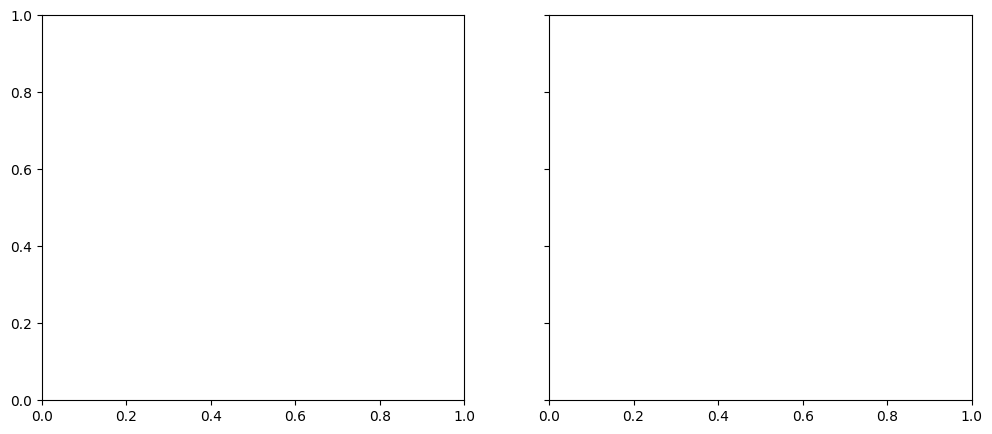

In [20]:
plot_weighted_samples(X, true_samples, weights_, labels, labels_true)

In [ ]:
# plot_annealed_langevin(means, modes, true_modes, mixture, device, load_dir)

### NETS

In [ ]:
# x0 = torch.randn(num_samples, dim, device=device)
A0 = torch.zeros(num_samples, device=device)
x_nets, A_nets = NET_Sampler(drift, 
                            x0, 
                            A0, 
                            dt = dt,
                            steps=n_steps, 
                            epsilon=epsilon, 
                            means=means, 
                            U_net=potential_net, 
                            modes=modes,
                            mixture=mixture,
                            prior=prior,
                            energy_model=energy_model,
                            true_modes=true_modes,
                            true_samples=true_samples,
                            device=device)
ess_nets = ess_eval(A_nets)
print(ess_nets)

In [22]:
X_, log_weights = x_nets[-1], A_nets[-1]
weights_ = log_weights.exp()

labels_ = label_assignment_hard(X_, true_modes)

w = normalize_weights(weights_)

mode_weights = torch.stack([
    w[labels == k].sum()
    for k in torch.unique(labels_)
])

print(mode_weights)

tensor([0.4848, 0.5152])


In [23]:
w2 = weighted_w2(X, true_samples, weights_)
w2

1.0204708410741794

with component balance
- 0.5, 0.5 (1, 2) 32
- (0.55, 0.44, 26.3), (0.49, 0.51, 10.3), (0.6, 0.4, 30.9)

- 0.5, 0.5, (1, 3) 32
- (0.69, 0.31, 51)
- (0.53, 0.47, 13.8), (0.52, 0.48, 16.6), (0.61, 0.39, 33.6) (1e-2, 1e12)

- 0.5, 0.5, (1, 4) 32
- (0.49, 0.51, 15.1), (0.83, 0.37, 67.2), (0.61, 0.39, 33.6) (1e-2, 1e12)

- 0.7, 0.3, (1, 3) 32
- (0.78, 0.22, 33.6), (0.9, 0.1, 51.5) (1e-2, 1e12)

without component balance
- 0.5, 0.5 (1, 2) 32
- (0.95, 0.05, 79), (0.73, 0.27, 55.5), (0.01, 0.99, 70.5)

- 0.5, 0.5, (1, 3) 32
- (0.96, 0.04, 79.4)
- (0.59, 0.41, 32.7) (0.85, 0.15, 69.4), (0.62, 0.38, 36) (1e-2)

- 0.5, 0.5, (1, 4) 32
- (0.62, 0.38, 35), (0.95, 0.05, 79.8), (0.61, 0.39, 33.6) (1e-2, 1e12)


with just lin int
- 0.5, 0.5 (1, 4)
- 32 : (0.78, 0.22, 63), (0.38, 0.62, 38), (0.02, 0.98, 71.2)
- 64 : (0.75, 0.25), (0.38, 0.62), (0.65, 0.35)
- 96 : (0.55, 0.45), (0.55, 0.45), (0.31, 0.69)

with mode balance
- 0.5, 0.5 (1, 4)
- 32 : (0.78, 0.22, 63), (0.38, 0.62, 38), (0.02, 0.98, 71.2)

2d, perturb 0.0, beta_max=10
-0.342, 0.658 (covs = (0.1, 0.1))
-0.333, 0.667 (covs = (0.1, 0.3))
-0.324, 0.676 (covs = (1, 1))
-0.367, 0.633 (covs = (1, 3))

2d, perturb 1.0, beta_max=10
-0.341, 0.659 (covs = (0.1, 0.1))
-0.333, 0.667 (covs = (0.1, 0.3))
-0.324, 0.676 (covs = (1, 1))
-0.367, 0.633 (covs = (1, 3))

8d, perturb 0.0, beta_max=10
- 0.3438, 0.6562 (covs = 0.1, 0.1)
- 0.325, 0.675 (covs = 0.1, 0.3)
- 0.29, 0.71 (covs = 1, 1)
- 0.3, 0.7 (covs 1, 3)

8d, perturb 0.0, beta_max=1
- 0.34, 0.66 (covs = 1, 1)
- 0.34, 0.66 (covs 1, 3)

8d, perturb 1.0, beta_max=1
- 0.34, 0.66 (covs = 1, 1)
- 0.34, 0.66 (covs 1, 3)

8d, perturb 1.0, beta_max=10
- 0.34, 0.66 (covs = 0.1, 0.1)
- 0.3233, 0.6767 (covs = 0.1, 0.3)
- 0.29, 0.71 (covs = 1, 1)
- 0.3, 0.7 (covs 1, 3)

#### Mode weights of 32, 64, 128d with 2 modes weighted as (0.3, 0.7) perturb 0.0 (modAlps vs lin int gmm)
mod alps (beta_max = 10.0)

- 32d : (1, 1) 0.98, 0.02 (w2 : 31.93) | (1,3) 0.99, 0.01 (w2: 32.42)  | (3,1) 0.97, 0.03 (32.20)
- 64d : (1, 1)  | (1,3)  | (3,1)
- 128d :(1, 1)  | (1,3)  | (3,1)

mod alps (beta_max = 1.0)

- 32d : (1, 1) 0.3, 0.7 (w2 : 10.38) | (1,3) 0.97, 0.03 (w2: 30.63)  | (3,1) 0.9, 0.1 (w2: 31.68)
- 64d : (1, 1)  | (1,3)  | (3,1)
- 128d :(1, 1)  | (1,3)  | (3,1)

gmm lin int

- 32d : (1,1) 0.7, 0.3 (w2 : 24) | 0.81 0.19 (w2: 27.22) (1,3)  | (3,1) 0.65, 0.35 (w2 : 22.73)
- 64d : (1, 1)  | (1,3)  | (3,1)
- 128d :(1, 1)  | (1,3)  | (3,1)

2d, perturb 0.0, beta_max=10
-0.342, 0.658 (covs = (0.1, 0.1))
-0.333, 0.667 (covs = (0.1, 0.3))
-0.324, 0.676 (covs = (1, 1))
-0.367, 0.633 (covs = (1, 3))

2d, perturb 1.0, beta_max=10
-0.341, 0.659 (covs = (0.1, 0.1))
-0.333, 0.667 (covs = (0.1, 0.3))
-0.324, 0.676 (covs = (1, 1))
-0.367, 0.633 (covs = (1, 3))


In [ ]:
# plot_annealed_langevin(means, modes, true_modes, mixture, device, load_dir, is_ais=False)

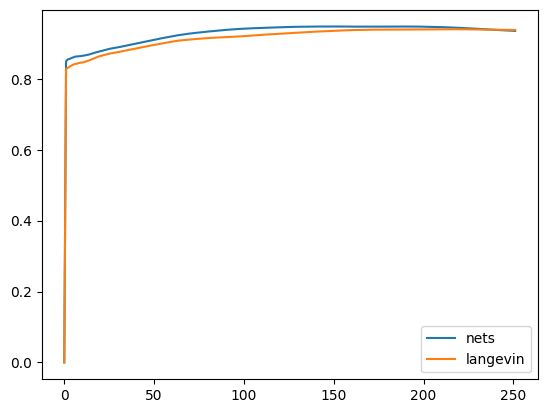

In [24]:
plt.plot(ess_nets, label='nets')
plt.plot(ess_langevin, label='langevin')
plt.legend()
plt.show()

In [ ]:
# plot_nets(means, modes, true_modes, mixture, device, load_dir)

## ALDP Runner

Use these cells to launch the Alanine dipeptide training script from this notebook through the dedicated `pita-aldp` environment.

In [7]:
from pathlib import Path
import os
import subprocess


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "Training" / "run_training.py").exists() and (candidate / "conf").exists():
            return candidate
    raise RuntimeError("Could not locate the NETS repo root from the notebook working directory.")


REPO_ROOT = find_repo_root()
ALDP_PYTHON = Path("/opt/homebrew/anaconda3/envs/pita-aldp/bin/python")
if not ALDP_PYTHON.exists():
    raise FileNotFoundError(f"Expected ALDP environment python at {ALDP_PYTHON}")

ALDP_ENV = os.environ.copy()
ALDP_ENV.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")
ALDP_ENV.setdefault("XDG_CACHE_HOME", "/tmp")
ALDP_ENV["MPLBACKEND"] = "Agg"
ALDP_ENV.setdefault("LOKY_MAX_CPU_COUNT", "8")

print("Repo root:", REPO_ROOT)
print("ALDP python:", ALDP_PYTHON)

Repo root: /Users/dilumfernando/projects/NETs
ALDP python: /opt/homebrew/anaconda3/envs/pita-aldp/bin/python


In [8]:
def run_aldp_training(*extra_overrides: str) -> None:
    cmd = [
        str(ALDP_PYTHON),
        "Training/run_training.py",
        "experiment=alps_aldp",
        *extra_overrides,
    ]
    print("Running:", " ".join(cmd))
    completed = subprocess.run(cmd, cwd=REPO_ROOT, env=ALDP_ENV, text=True)
    if completed.returncode != 0:
        raise RuntimeError(f"ALDP training failed with exit code {completed.returncode}")

In [9]:
# Quick smoke test
run_aldp_training(
    "training.steps=100",
    "training.n_walkers=1000",
    "data.true_sample_count=1000",
)

Running: /opt/homebrew/anaconda3/envs/pita-aldp/bin/python Training/run_training.py experiment=alps_aldp training.steps=100 training.n_walkers=1000 data.true_sample_count=1000
Running training with config:
training:
  n_walkers: 1000
  steps: 100
  epsilon: 0.01
  K: 50
  modal_loss_weight: 0.0
  modal_loss_end_fraction: 0.0
  loss_type: manual
data:
  target: aldp
  run_name: aldp_alps
  dim: 66
  num_components: 4
  n_particles: 22
  spatial_dim: 3
  temperature: 300.0
  should_normalize: true
  normalization_factor: 0.164
  should_remove_mean: true
  train_path: data/alanine/AL22_temp_300.00/train_split_AL22-10000.npy
  val_path: data/alanine/AL22_temp_300.00/val_split_AL22-10000.npy
  test_path: data/alanine/AL22_temp_300.00/test_split_AL22-10000.npy
  pdb_path: data/pdbs/A_capped.pdb
  mode_centers_path: null
  num_mode_centers: 4
  mode_estimation_samples: 10000
  mode_strategy: rama_kmeans
  energy_batch_size: 1024
  openmm_platform: CPU
  device_index: 0
  true_sample_count: 10

/opt/homebrew/anaconda3/envs/pita-aldp/lib/python3.10/site-packages/bgflow/distribution/energy/openmm.py:392: UserWarning: Suppressed exception: Particle coordinate is NaN.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#nan
  warnings.warn("Suppressed exception: {}".format(e))
/opt/homebrew/anaconda3/envs/pita-aldp/lib/python3.10/site-packages/bgflow/distribution/energy/openmm.py:392: UserWarning: Suppressed exception: Particle coordinate is NaN.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#nan
  warnings.warn("Suppressed exception: {}".format(e))
/opt/homebrew/anaconda3/envs/pita-aldp/lib/python3.10/site-packages/bgflow/distribution/energy/openmm.py:392: UserWarning: Suppressed exception: Particle coordinate is NaN.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#nan
  warnings.warn("Suppressed exception: {}".format(e))
/opt/homebrew/anaconda3/envs/pi

KeyboardInterrupt: 

In [ ]:
def run_aldp_eval(*extra_overrides: str) -> None:
    cmd = [
        str(ALDP_PYTHON),
        "Testing/run_eval.py",
        "experiment=alps_aldp",
        *extra_overrides,
    ]
    print("Running:", " ".join(cmd))
    completed = subprocess.run(cmd, cwd=REPO_ROOT, env=ALDP_ENV, text=True)
    if completed.returncode != 0:
        raise RuntimeError(f"ALDP eval failed with exit code {completed.returncode}")


def run_aldp_tica_plot(*extra_overrides: str) -> None:
    cmd = [
        str(ALDP_PYTHON),
        "Testing/run_aldp_tica.py",
        "experiment=alps_aldp",
        *extra_overrides,
    ]
    print("Running:", " ".join(cmd))
    completed = subprocess.run(cmd, cwd=REPO_ROOT, env=ALDP_ENV, text=True)
    if completed.returncode != 0:
        raise RuntimeError(f"ALDP TICA plotting failed with exit code {completed.returncode}")

In [ ]:
# After training succeeds, generate samples and save eval artifacts
run_aldp_eval(
    "eval.num_samples=512",
    "eval.true_sample_count=512",
    "eval.steps=50",
    "eval.plot_every=0",
)

In [ ]:
# Then create the TICA comparison plot of generated vs true samples
run_aldp_tica_plot()